In [1]:
# Cryptocurrency Halal/Haram Classifier - Complete ML Workflow
# Save this as: notebooks/crypto_classifier_workflow.ipynb

In [2]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


In [3]:
# Cell 2: Load and Explore Data
print("=" * 80)
print("STEP 1: DATA LOADING AND EXPLORATION")
print("=" * 80)

# Create expanded dataset with 100 cryptocurrencies
data = {
    'crypto_name': [
        # Major cryptocurrencies (1-20)
        'Bitcoin', 'Ethereum', 'Tether', 'BNB', 'XRP', 'Cardano', 'Dogecoin', 'Solana', 
        'USDC', 'Polygon', 'Polkadot', 'Litecoin', 'Avalanche', 'Chainlink', 'Uniswap',
        'Stellar', 'Algorand', 'VeChain', 'Cosmos', 'Hedera',
        
        # DeFi & Lending Platforms (21-35)
        'Aave', 'Compound', 'PancakeSwap', 'SushiSwap', 'Curve', 'Maker', 'Yearn',
        'Synthetix', 'Balancer', 'Bancor', 'dYdX', 'Venus', 'JustLend', 'Euler', 'Morpho',
        
        # Stablecoins (36-45)
        'Dai', 'BUSD', 'TrueUSD', 'Pax Dollar', 'USDD', 'Frax', 'TUSD', 'USDP', 'GUSD', 'LUSD',
        
        # Layer 2 & Scaling (46-55)
        'Arbitrum', 'Optimism', 'zkSync', 'StarkNet', 'Loopring', 'Immutable X', 
        'Boba Network', 'Metis', 'Aztec', 'Scroll',
        
        # Smart Contract Platforms (56-65)
        'Tron', 'EOS', 'NEAR', 'Flow', 'Elrond', 'Zilliqa', 'Harmony', 'Fantom', 
        'Tezos', 'Klaytn',
        
        # Gaming & NFT (66-75)
        'Axie Infinity', 'Decentraland', 'The Sandbox', 'Enjin', 'Gala', 'ApeCoin',
        'Immutable', 'WAX', 'Ultra', 'MyNeighborAlice',
        
        # Oracles & Infrastructure (76-85)
        'Band Protocol', 'API3', 'Tellor', 'DIA', 'Pyth Network', 'Nest Protocol',
        'UMA', 'Razor Network', 'Witnet', 'Umbrella Network',
        
        # Privacy Coins (86-90)
        'Monero', 'Zcash', 'Dash', 'Horizen', 'Beam',
        
        # Meme & Speculative (91-100)
        'Shiba Inu', 'Pepe', 'Floki', 'Baby Doge', 'SafeMoon', 'Dogelon Mars',
        'Kishu Inu', 'Akita Inu', 'Hoge Finance', 'Samoyedcoin'
    ],
    'has_interest_mechanism': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
    'has_gambling_elements': [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1],
    'excessive_speculation': [1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    'has_real_utility': [1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    'transparency_score': [8,9,9,8,7,9,5,8,10,8,8,7,8,9,7,9,9,7,8,8,8,8,7,7,7,9,7,7,7,7,7,6,6,7,7,9,9,8,8,7,8,8,8,9,8,8,8,7,7,7,7,7,7,6,7,7,6,8,8,8,7,7,7,8,7,6,6,6,7,6,5,7,6,6,6,7,7,6,7,7,6,6,6,6,6,5,6,5,5,5,4,3,4,4,3,3,3,3,3,3],
    'asset_backed': [0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'defi_lending': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'is_halal': [1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(data)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Cryptocurrencies: {len(df)}")
print(f"Halal: {sum(df['is_halal'])} ({sum(df['is_halal'])/len(df)*100:.1f}%)")
print(f"Haram: {len(df) - sum(df['is_halal'])} ({(len(df)-sum(df['is_halal']))/len(df)*100:.1f}%)")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
display(df.info())

print("\nStatistical Summary:")
display(df.describe())

STEP 1: DATA LOADING AND EXPLORATION

Dataset Shape: (100, 9)
Total Cryptocurrencies: 100
Halal: 67 (67.0%)
Haram: 33 (33.0%)

First 5 rows:


,crypto_name,has_interest_mechanism,has_gambling_elements,excessive_speculation,has_real_utility,transparency_score,asset_backed,defi_lending,is_halal
0,Bitcoin,0,0,1,1,8,0,0,1
1,Ethereum,0,0,0,1,9,0,0,1
2,Tether,0,0,0,1,9,1,0,1
3,BNB,0,0,0,1,8,0,0,1
4,XRP,0,0,1,1,7,0,0,1



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   crypto_name             100 non-null    str  
 1   has_interest_mechanism  100 non-null    int64
 2   has_gambling_elements   100 non-null    int64
 3   excessive_speculation   100 non-null    int64
 4   has_real_utility        100 non-null    int64
 5   transparency_score      100 non-null    int64
 6   asset_backed            100 non-null    int64
 7   defi_lending            100 non-null    int64
 8   is_halal                100 non-null    int64
dtypes: int64(8), str(1)
memory usage: 7.2 KB


None


Statistical Summary:


,has_interest_mechanism,has_gambling_elements,excessive_speculation,has_real_utility,transparency_score,asset_backed,defi_lending,is_halal
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.170000,0.160000,0.250000,0.880000,6.780000,0.120000,0.160000,0.670000
std,0.377525,0.368453,0.435194,0.326599,1.580052,0.326599,0.368453,0.472582
min,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,7.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.250000,1.000000,8.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000


STEP 2: EXPLORATORY DATA ANALYSIS


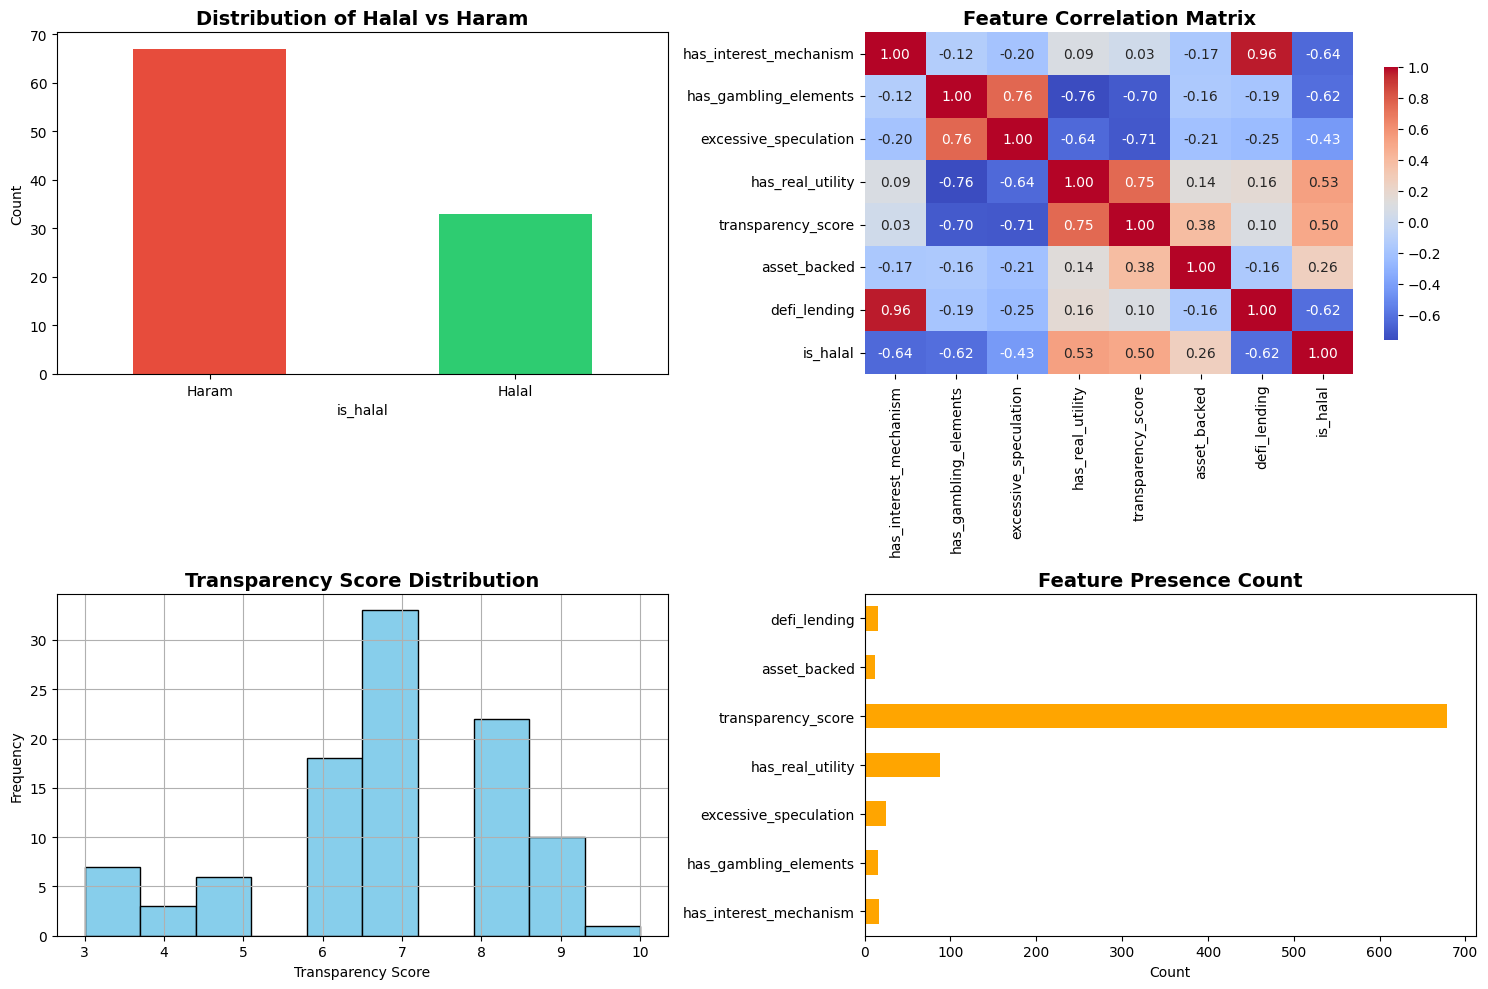

In [4]:
# Cell 3: Data Visualization
print("=" * 80)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of Halal vs Haram
ax1 = axes[0, 0]
df['is_halal'].value_counts().plot(kind='bar', ax=ax1, color=['#e74c3c', '#2ecc71'])
ax1.set_title('Distribution of Halal vs Haram', fontsize=14, fontweight='bold')
ax1.set_xticklabels(['Haram', 'Halal'], rotation=0)
ax1.set_ylabel('Count')

# Feature correlation heatmap
ax2 = axes[0, 1]
corr_matrix = df.drop('crypto_name', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Transparency score distribution
ax3 = axes[1, 0]
df['transparency_score'].hist(bins=10, ax=ax3, color='skyblue', edgecolor='black')
ax3.set_title('Transparency Score Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Transparency Score')
ax3.set_ylabel('Frequency')

# Feature importance preview
ax4 = axes[1, 1]
feature_counts = df.drop(['crypto_name', 'is_halal'], axis=1).sum()
feature_counts.plot(kind='barh', ax=ax4, color='orange')
ax4.set_title('Feature Presence Count', fontsize=14, fontweight='bold')
ax4.set_xlabel('Count')

plt.tight_layout()
plt.show()


In [5]:
# Cell 4: Data Preparation
print("=" * 80)
print("STEP 3: DATA PREPARATION")
print("=" * 80)

X = df.drop(['crypto_name', 'is_halal'], axis=1)
y = df['is_halal']

feature_names = X.columns.tolist()
print(f"\nFeatures: {feature_names}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")
print(f"\nClass distribution in training set:")
print(f"Halal: {sum(y_train)}, Haram: {len(y_train) - sum(y_train)}")

STEP 3: DATA PREPARATION

Features: ['has_interest_mechanism', 'has_gambling_elements', 'excessive_speculation', 'has_real_utility', 'transparency_score', 'asset_backed', 'defi_lending']

Training set: 75 samples
Testing set: 25 samples

Class distribution in training set:
Halal: 50, Haram: 25


In [6]:
# Cell 5: Train Base Models (Default Parameters)
print("=" * 80)
print("STEP 4: TRAINING BASE MODELS (DEFAULT PARAMETERS)")
print("=" * 80)

base_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

base_results = []

for name, model in base_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    base_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Score': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"✓ {name} - Accuracy: {accuracy*100:.2f}%, F1: {f1*100:.2f}%")

base_results_df = pd.DataFrame(base_results).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 80)
print("BASE MODEL RESULTS (DEFAULT PARAMETERS)")
print("=" * 80)
display(base_results_df)

# Identify top 2 models
top_2_models = base_results_df.head(2)['Model'].tolist()
print(f"\n🏆 Top 2 Models: {top_2_models[0]} and {top_2_models[1]}")

print("\n✓ Base model training complete!")
print("✓ Notebook ready for hyperparameter tuning and deep learning!")

STEP 4: TRAINING BASE MODELS (DEFAULT PARAMETERS)

Training Random Forest...
✓ Random Forest - Accuracy: 100.00%, F1: 100.00%

Training Gradient Boosting...
✓ Gradient Boosting - Accuracy: 100.00%, F1: 100.00%

Training SVM...
✓ SVM - Accuracy: 92.00%, F1: 94.44%

Training KNN...
✓ KNN - Accuracy: 96.00%, F1: 97.14%

Training Decision Tree...
✓ Decision Tree - Accuracy: 100.00%, F1: 100.00%

Training Naive Bayes...
✓ Naive Bayes - Accuracy: 100.00%, F1: 100.00%

Training Logistic Regression...
✓ Logistic Regression - Accuracy: 100.00%, F1: 100.00%

BASE MODEL RESULTS (DEFAULT PARAMETERS)


,Model,Accuracy,Precision,Recall,F1-Score,CV Score,CV Std
0,Random Forest,1.00,1.000000,1.0,1.000000,0.986667,0.026667
1,Gradient Boosting,1.00,1.000000,1.0,1.000000,0.986667,0.026667
4,Decision Tree,1.00,1.000000,1.0,1.000000,0.986667,0.026667
6,Logistic Regression,1.00,1.000000,1.0,1.000000,0.986667,0.026667
5,Naive Bayes,1.00,1.000000,1.0,1.000000,1.000000,0.000000
3,KNN,0.96,0.944444,1.0,0.971429,0.960000,0.053333
2,SVM,0.92,0.894737,1.0,0.944444,0.813333,0.097980



🏆 Top 2 Models: Random Forest and Gradient Boosting

✓ Base model training complete!
✓ Notebook ready for hyperparameter tuning and deep learning!
